# IT0002 — One-Hot Encoding
**Member 2 — Preprocessing Technique: One-Hot Encoding**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish.

## 1. Introduction

**One-Hot Encoding** creates a new binary (0/1) column for every category value in every
feature. Unlike label encoding it implies **no false ordering** between categories, which makes
it the natural choice for **linear models and neural networks** that would otherwise
misinterpret integer-coded categories as having magnitude. The trade-off is a large increase
in the number of columns (dimensionality).

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

**Missing-value strategy chosen: 'unknown' category.**
Rather than imputing a guessed value, `stalk-root` missing entries are given their own explicit
`'unknown'` category. This is a natural fit for one-hot encoding, since it simply becomes one
more dummy column (`stalk-root_unknown`) instead of forcing an artificial guess onto ~30% of
the data.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# veil-type has only 1 unique value across the whole dataset -> no predictive
# information at all, so every member drops it after noting this.
print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

# Strategy: replace missing stalk-root with an explicit 'unknown' category
df['stalk-root'] = df['stalk-root'].fillna('unknown')
print(df['stalk-root'].value_counts())

print()
print("Missing values remaining:", df.isnull().sum().sum())

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage per column:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises              

/var/folders/ln/lpsmr0qd3673cmmw327l0g1m0000gn/T/ipykernel_27618/2767192073.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].fillna('unknown', inplace=True)


## 4. Apply One-Hot Encoding

`pd.get_dummies()` is applied to all feature columns. `drop_first=True` is used to drop one
dummy column per feature to avoid perfect multicollinearity (the "dummy variable trap"), which
matters for linear models such as Logistic Regression; tree/ensemble models are unaffected
either way.

In [3]:
feature_cols = [c for c in df.columns if c != 'class']
shape_before = df.shape
print("Shape before one-hot encoding:", shape_before)

df = pd.get_dummies(df, columns=feature_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
df.head()

Shape before one-hot encoding: (8124, 22)
Shape after one-hot encoding: (8124, 95)


,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,p,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,e,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,e,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,p,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,e,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


**Note:** One-hot encoding implies no false ordering between categories, which is
correct for these nominal features. The cost is dimensionality — this dataset grows from ~21
feature columns to 90+ binary columns. That is fine for **linear models and neural networks**
(each binary flag is just an independent input weight), but it is **less ideal for
distance-based models like KNN**, where the inflated, sparse binary space distorts distance
calculations between points.

## 5. Encode Target Variable

In [4]:
df['class'] = df['class'].map({'e': 0, 'p': 1})
print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
0    4208
1    3916
Name: count, dtype: int64

Class balance (%):
class
0    51.8
1    48.2
Name: proportion, dtype: float64


## 6. EDA Visualization

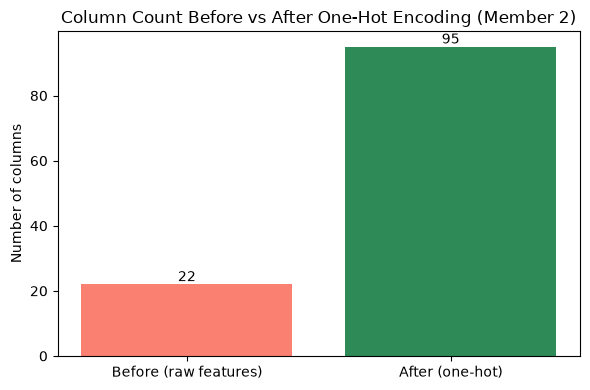

In [5]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Before (raw features)', 'After (one-hot)'], [22, df.shape[1]], color=['salmon', 'seagreen'])
ax.set_ylabel('Number of columns')
ax.set_title('Column Count Before vs After One-Hot Encoding (Member 2)')
for i, v in enumerate([22, df.shape[1]]):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M2_onehot_encoding.png', dpi=150)
plt.show()

## 7. Save Output

In [6]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M2_onehot_encoded.csv', index=False)
print("Saved: ../results/outputs/step_M2_onehot_encoded.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M2_onehot_encoded.csv
Final shape: (8124, 95)
